In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

from math import pi

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tqdm.contrib.itertools
import xarray as xr

from fluxoniumcr.qubits.fluxonium import Fluxonium


plt.style.use("fluxoniumcr.plotting.paper")

In [2]:
dataset = xr.Dataset()

a_data = np.linspace(6, 11, 401) * pi/12

# Keep only EL/EJ < 0.5
a_data = a_data[a_data > 1.89477]
b_data = np.unique(
    np.round(
        np.concatenate([
             1/np.linspace(2, 0, num=200, endpoint=False),
            np.arange(1, 11),
        ]),
        decimals=8,
    ),
)

a_coord = xr.DataArray(
    a_data,
    dims=['a'],
)
b_coord = xr.DataArray(
    b_data,
    dims=['b'],
)
i_coord = xr.DataArray(
    np.arange(4),
    dims=['i'],
)
j_coord = xr.DataArray(
    i_coord.data,
    dims=['j'],
)

dataset['EL_div_EJ'] = xr.DataArray(
    np.sinc(a_coord/pi),
    coords=[a_coord],
)
dataset['EC'] = xr.DataArray(
    (a_coord/pi)**2,
    coords=[a_coord],
    attrs=dict(
        unit="Grad/s"
    )
)
dataset['EJ'] = xr.DataArray(
    np.nan,
    coords=[a_coord, b_coord],
    attrs=dict(
        unit="Grad/s"
    )
)
dataset['evals'] = xr.DataArray(
    np.nan,
    coords=[a_coord, b_coord, i_coord],
    attrs=dict(
        unit="Grad/s"
    )
)
dataset['phi'] = xr.DataArray(
    np.nan,
    coords=[a_coord, b_coord, i_coord, j_coord]
)
dataset['charge'] = xr.DataArray(
    np.nan,
    coords=[a_coord, b_coord, i_coord, j_coord]
)

In [3]:
for a, b in tqdm.contrib.itertools.product(
        dataset.a.data,
        dataset.b.data,
):
    ds = dataset.loc[dict(a=a, b=b)]
    EJ = b/(1 - a*np.sin(a)/2 - np.cos(a))
    EC = ds['EC'].item()
    EL = ds['EL_div_EJ'].item() * EJ
    fx = Fluxonium(
        EJ=EJ,
        EC=EC,
        EL=EL,
        flux=0.5,
        cutoff=64,
        dim=len(dataset.i),
    )
    evals = fx.eigenvalues
    phi_op, charge_op = fx.get_operators(['phi', 'charge'])
    ds['EJ'][()] = EJ
    ds['evals'][:] = evals
    ds['phi'][:] = phi_op
    ds['charge'][:] = charge_op.imag

  0%|          | 0/61910 [00:00<?, ?it/s]

In [57]:
from matplotlib.colors import LinearSegmentedColormap

myblues = LinearSegmentedColormap.from_list(
    "myblues",
    [
        "#f7fbff",
        "#deebf7",
        "#c6dbef",
        "#9ecae1",
        "#6baed6",
        "#4292c6",
        "#2171b5",
        "#08519c",
        "#08306b",
    ]
)

In [58]:
def add_subfig_label(ax, label):
    annotation = ax.annotate(
        label,
        (0.00, 1.00),
        (-20, 0),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="right",
        va="top",
        zorder=1,
    )
    return annotation

Text(-20, 0, 'd')

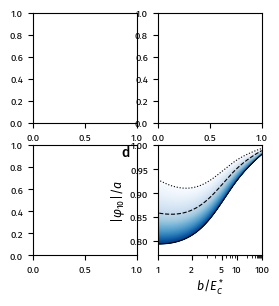

In [103]:
fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(75/25.4, 80/25.4),
)

ax = axs[1, 1]

cmap = myblues.reversed()
norm = plt.Normalize(dataset.a.min(), dataset.a.max())

p = 0.5
segments = [
    np.column_stack(
        [
            (1/dataset.b)**p,
            data,
        ]
    )
    for data in abs(dataset.phi.isel(i=0, j=1))/dataset.a
]

lc = mpl.collections.LineCollection(
    segments,
    colors=cmap(norm(dataset.a)),
    lw=plt.rcParams['grid.linewidth']/2,
    rasterized=True
)

ax.add_collection(lc)

for i, a in enumerate([dataset.a.data[0], 2.6, dataset.a.data[-1]]):
# for i, a in enumerate([1.9, 2.6, 2.854]):
    ds = dataset.sel(a=a, method='nearest')
    ls = ['-', '--', ':'][i]
    ax.plot(
        (1/ds.b)**p,
        abs(ds.phi.isel(i=0, j=1))/a,
        lw=plt.rcParams['grid.linewidth'],
        ls=ls,
        c='black',
    )
    
ax.set_ylabel(r"$|\varphi_{10}|/a$", labelpad=2)

ax.set_xlim(1/100**p, 1)
ax.set_xticks(
    [
        1,
        1/2**p,
        1/5**p,
        1/10**p,
        1/100**p,
    ],
    [
        1,
        2,
        5,
        10,
        100,
    ]
)
ax.set_xticks(
    [
        *[1/x**p for x in range(3, 5)],
        *[1/x**p for x in range(6, 10)],
        *[1/(10*x)**p for x in range(2, 10)],
    ],
    minor=True,
)
ax.invert_xaxis()

ax.set_ylim(0.77, 1.0)
ax.set_xlabel(r"$b/E_C^*$", labelpad=2)

add_subfig_label(ax, "d")

# fig
# plt.savefig("test.pdf", dpi=300)

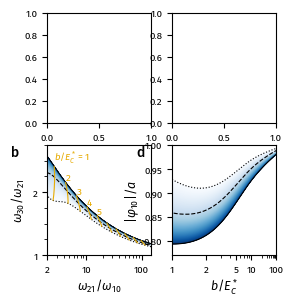

In [104]:
ax = axs[1, 0]

ax.clear()

p = 0.5
segments = []
for a in dataset.a:
    ds = dataset.loc[dict(a=a)]
    f10 = ds.evals.sel(i=1) - ds.evals.sel(i=0)
    f21 = ds.evals.sel(i=2) - ds.evals.sel(i=1)
    f30 = ds.evals.sel(i=3) - ds.evals.sel(i=0)
    segments.append(np.column_stack([f21/f10, f30/f21]))

lc = mpl.collections.LineCollection(
    segments,
    colors=cmap(norm(dataset.a)),
    lw=plt.rcParams['grid.linewidth']/2,
    rasterized=True,
)
ax.add_collection(lc)
    

for i, a in enumerate([dataset.a.data[0], 2.6, dataset.a.data[-1]]):
# for i, a in enumerate([1.9, 2.6, 2.854]):
    ds = dataset.sel(a=a, method='nearest')
    ls = ['-', '--', ':'][i]
    ds = dataset.sel(a=a, method='nearest')
    f10 = ds.evals.sel(i=1) - ds.evals.sel(i=0)
    f21 = ds.evals.sel(i=2) - ds.evals.sel(i=1)
    f30 = ds.evals.sel(i=3) - ds.evals.sel(i=0)
    ax.plot(
        f21/f10,
        f30/f21,
        lw=plt.rcParams['grid.linewidth'],
        ls=ls,
        c='black',
        solid_capstyle='round',
    )

for b in range(1, 11):
    ds = dataset.sel(b=b, method='nearest')
    f10 = ds.evals.sel(i=1) - ds.evals.sel(i=0)
    f21 = ds.evals.sel(i=2) - ds.evals.sel(i=1)
    f30 = ds.evals.sel(i=3) - ds.evals.sel(i=0)
    x_data = (f21/f10).data
    y_data = (f30/f21).data
    ax.plot(
        x_data,
        y_data,
        c='C3',
        lw=plt.rcParams['grid.linewidth'],
        solid_capstyle='round',
    )
    if b == 1:
        ax.annotate(
            "$b/E_C^*=1$",
            (x_data[0], y_data[0]),
            c='C3',
            fontsize=plt.rcParams['xtick.labelsize'],
            ha='left',
            va='bottom',
        )
    elif 2 <= b <= 5:
        ax.annotate(
            b,
            (x_data[0], y_data[0]),
            c='C3',
            fontsize=plt.rcParams['xtick.labelsize'],
            ha='left',
            va='bottom',
        )
        

ax.set_ylim(1, 2.75)
ax.set_yticks([1, 2])
ax.set_yticks([1.25, 1.5, 1.75, 2.25, 2.5, 2.75], minor=True)

ax.set_xscale('log')
ax.set_xlim(2, 150)
ax.set_xticks([2, 10, 100], [2, 10, 100])

# ax.plot(
#     [1, 1e3], [1, 1e3],
#     c=plt.rcParams['grid.color'],
#     lw=plt.rcParams['grid.linewidth'],
# )

ax.set_xlabel(r"$\omega_{21}/\omega_{10}$", labelpad=2)
ax.set_ylabel(r"$\omega_{30}/\omega_{21}$")


add_subfig_label(ax, "b")

fig

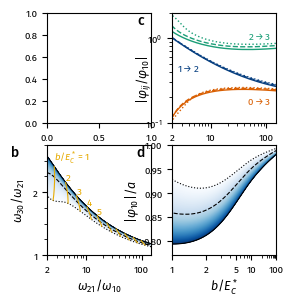

In [105]:
ax = axs[0, 1]
ax.clear()

for i, a in enumerate([dataset.a.data[0], 2.6, dataset.a.data[-1]]):
# for i, a in enumerate([1.9, 2.6, 2.854]):
    ds = dataset.sel(a=a, method='nearest')
    ls = ['-', '--', ':'][i]
    f10 = ds.evals.sel(i=1) - ds.evals.sel(i=0)
    f21 = ds.evals.sel(i=2) - ds.evals.sel(i=1)
    phi10 = abs(ds.phi.sel(i=1, j=0))
    phi21 = abs(ds.phi.sel(i=2, j=1))
    phi30 = abs(ds.phi.sel(i=3, j=0))
    phi32 = abs(ds.phi.sel(i=3, j=2))
    x = f21/f10
#     x = ds.b
    ax.plot(x, phi21/phi10, c='C0', ls=ls)
    ax.plot(x, phi30/phi10, c='C1', ls=ls)
    ax.plot(x, phi32/phi10, c='C4', ls=ls)
#     plt.plot(data[i], elm23[i])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2, 150)
ax.set_xticks([2, 10, 100], [2, 10, 100])

ax.set_ylim(1e-1, 2)

ax.set_xlabel(r"$\omega_{21}/\omega_{10}$", labelpad=2)
ax.set_ylabel(r"$|\varphi_{ij}/\varphi_{10}|$", labelpad=-5.5)
ax.yaxis.label.set_position((0, 0.4))


fontsize = plt.rcParams['xtick.labelsize']
ax.annotate(
    r"$2\to3$",
    (0.95, 0.74),
    xycoords='axes fraction',
    c="C4",
    fontsize=fontsize,
    ha='right',
    va='bottom',
)

ax.annotate(
    r"$1\to2$",
    (0.05, 0.55),
    xycoords='axes fraction',
    c="C0",
    fontsize=fontsize,
    ha='left',
    va='top',
)

ax.annotate(
    r"$0\to3$",
    (0.95, 0.25),
    xycoords='axes fraction',
    c="C1",
    fontsize=fontsize,
    ha='right',
    va='top',
)

add_subfig_label(ax, "c")

fig

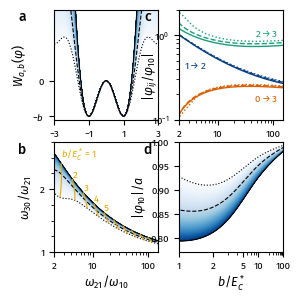

In [106]:
def fx_potential(a, b, phi):
    return b * (
        (0.5 * np.sinc(a/pi) * phi**2 + np.cos(phi) - 1)
        / (1 - 0.5*a*np.sin(a) - np.cos(a))
    )

ax = axs[0, 0]

a_values = np.linspace(dataset.a.data.min(), dataset.a.data.max(), 2000)
xx = np.linspace(-3, 3, 100)
segments = []
for a in a_values:
    yy = fx_potential(a, 1, a*xx)
    segments.append(np.column_stack([xx, yy]))

lc = mpl.collections.LineCollection(
    segments,
    colors=cmap(norm(a_values)),
    lw=plt.rcParams['grid.linewidth']/2,
    rasterized=True,
)
ax.add_collection(lc)

for i, a in enumerate([dataset.a.data[0], 2.6, dataset.a.data[-1]]):
    ls = ['-', '--', ':'][i]
    ax.plot(
        xx,
        fx_potential(a, 1, a*xx),
        lw=plt.rcParams['grid.linewidth'],
        ls=ls,
        c='black',
        solid_capstyle='round',
    )

ax.set_xlim(-3, 3)
ax.set_xticks([-3, -1, 1, 3])
ax.set_xlabel(r"$\varphi/a$", labelpad=2)

ax.set_ylabel(r"$W_{a,b}(\varphi)$", labelpad=2)
ax.set_yticks([-1, 0], ["$-b$", "$0$"])

ax.set_ylim(-1.1, 2)


add_subfig_label(ax, "a")

fig

In [107]:
# ax.remove()
ax = fig.add_axes([
    (0.12 + 0.97)/2 - 0.3/2,
    0.06,
    0.3,
    0.033,
])

ax.spines[['left', 'right']].set_visible(False)
ax.tick_params(axis='y', left=False, labelleft=False)

hm_x = dataset.EL_div_EJ.data.copy()
hm_z = cmap(norm(dataset.a))
ax.pcolormesh(hm_x, [0, 1], [hm_z[:-1]], rasterized=True)

col = 'C5'
ax.axvline(
    hm_x[0],
    ls='-',
    lw=plt.rcParams['xtick.major.width'],
    c=col,
    clip_on=False,
)
tick_pos = dataset.EL_div_EJ.sel(a=2.6, method='nearest').item()
ax.plot(
    [tick_pos]*2,
    [1, 0],
    ls=(0, (2, 1.5)),
    lw=plt.rcParams['xtick.major.width'],
    c=col,
    clip_on=False,
)
ax.plot(
    [hm_x[-1]]*2,
    [1, 0],
    ls=(0, (1, 1)),
    lw=plt.rcParams['xtick.major.width'],
    c=col,
    clip_on=False,
)

offset = tick_pos - 0.2
ax.set_xticks([0.2 + offset, 0.4 + offset], minor=True)
ax.set_xticks([dataset.EL_div_EJ.min(), 0.3, dataset.EL_div_EJ.max()], [0.1, 0.3, 0.5])


# ax.set_ylabel(
#     "$E_L/E_J$",
#     rotation=0,
#     ha='center',
#     va='center',
#     labelpad=15,
# )
ax.set_title("$E_L/E_J$", fontsize=plt.rcParams['axes.labelsize'], pad=1)

Text(0.5, 1.0, '$E_L/E_J$')

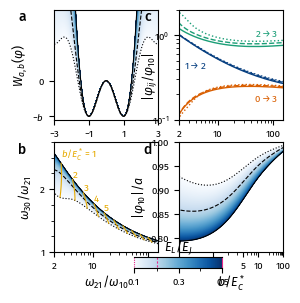

In [108]:
fig

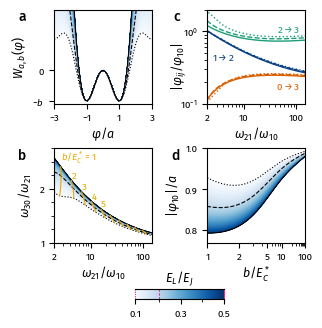

In [109]:

fig.subplots_adjust(
    wspace=0.57,
    hspace=0.47,
    left=0.12,
    right=0.97,
    bottom=0.24,
    top=0.98,
)

fig

In [110]:
fig.savefig("double_well_renorm.pdf", dpi=300)